In [1]:
!pip install smolagents[litellm] pandas matplotlib ddgs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 33.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.7/155.7 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 13.6 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.5.0
    Uninstalling huggingface_hub-1.5.0:
      Successfully uninstalled huggingface_hub-1.5.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
transformers 5.0.0 requires huggingface-hub<2.0,>=1.3.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [19]:
import os
import io
import sys
import traceback
import pandas as pd
from google.colab import drive, userdata
from smolagents import CodeAgent, InferenceClientModel, tool


drive.mount("/content/drive")

# ── 2. HuggingFace token from Colab Secrets ───────────────────────────────────
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
model = InferenceClientModel(model_id="Qwen/Qwen2.5-Coder-32B-Instruct")

# ── 3. Verify the file exists before running the agent ────────────────────────
CSV_PATH = "/content/drive/MyDrive/report generator project/tips.csv"

if not os.path.exists(CSV_PATH):
    # Fallback: upload manually to Colab's local storage
    from google.colab import files
    print("File not found in Drive. Please upload tips.csv manually:")
    uploaded = files.upload()
    CSV_PATH = list(uploaded.keys())[0]
    print(f"Using uploaded file: {CSV_PATH}")
else:
    print(f"✅ File found: {CSV_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File not found in Drive. Please upload tips.csv manually:


Saving tips.csv to tips.csv
Using uploaded file: tips.csv


In [20]:
@tool
def load_csv(csv_path: str) -> str:
    """
    Loads a CSV file and returns its column names and a sample of 5 rows
    as a markdown string, so the agent knows the schema.
    Args:
        csv_path: path to the CSV file
    """
    df = pd.read_csv(csv_path)
    sample = df.sample(min(5, len(df))).to_markdown()
    cols = df.dtypes.to_string()
    return f"## Columns & Types\n{cols}\n\n## Sample rows\n{sample}"


In [25]:
@tool
def run_analysis(csv_path: str, code: str) -> str:
    """
    Executes a pandas/matplotlib Python code string against the CSV.
    Returns stdout output or any error message.
    Args:
        csv_path: path to the CSV file
        code: valid Python code to run against a 'df' DataFrame
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt

    df = pd.read_csv(csv_path)
    buf = io.StringIO()
    try:
        sys.stdout = buf
        exec(code, {"df": df, "pd": pd, "plt": plt})
        sys.stdout = sys.__stdout__
        return buf.getvalue() or "Code executed successfully (no printed output)."
    except Exception:
        sys.stdout = sys.__stdout__
        return f"ERROR:\n{traceback.format_exc()}"


In [26]:
agent = CodeAgent(
    tools=[load_csv, run_analysis],
    model=model,
    max_steps=10,
    add_base_tools=False,
    # ✅ This is the key fix — allows agent to use these in its own code sandbox
    additional_authorized_imports=["pandas", "matplotlib", "matplotlib.pyplot",
                                   "numpy", "io", "os"],
)


In [27]:
USER_QUERY = "Summarize the dataset and show a bar chart of the top 5 categories by total bill."

result = agent.run(
    f"""
    You are a data analyst. The CSV file is at: {CSV_PATH}

    Task: {USER_QUERY}

    IMPORTANT RULES:
    - Always use load_csv("{CSV_PATH}") first to read the schema.
    - Always use run_analysis("{CSV_PATH}", code) to run any analysis.
    - NEVER hardcode or guess data values — always read from the real CSV.
    - The analysis code inside run_analysis already has 'df', 'pd', and 'plt' available.
      Do NOT re-import or re-read the CSV inside run_analysis code.
    - Save the chart with: plt.savefig("chart.png"); print("Chart saved.")
    - Print a markdown report with your findings.
    """
)

print(result)

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ You are a data analyst. The CSV file is at: tips.csv                                                            │
│                                                                                                                 │
│     Task: Summarize the dataset and show a bar chart of the top 5 categories by total bill.                     │
│                                                                                                                 │
│     IMPORTANT RULES:                                                                                            │
│     - Always use load_csv("tips.csv") first to read the schema.                                                 │
│     - Always use run_analysis("tips.csv", code) to run any analysis.                                            │
│     - NEVER hardcode or guess data values — always read from the real CSV.                                      │
│     - The analysis code inside run_analysis already has 'df', 'pd', and 'plt' available.                        │
│       Do NOT re-import or re-read the CSV inside run_analysis code.                                             │
│     - Save the chart with: plt.savefig("chart.png"); print("Chart saved.")                                      │
│     - Print a markdown report with your findings.                                                               │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-Coder-32B-Instruct ────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  schema_and_sample = load_csv("tips.csv")                                                                         
  print(schema_and_sample)                                                                                         
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Columns & Types
total_bill    float64
tip           float64
sex            object
smoker         object
day            object
time           object
size            int64

## Sample rows
|     |   total_bill |   tip | sex    | smoker   | day   | time   |   size |
|----:|-------------:|------:|:-------|:---------|:------|:-------|-------:|
|   6 |         8.77 |  2    | Male   | No       | Sun   | Dinner |      2 |
| 225 |        16.27 |  2.5  | Female | Yes      | Fri   | Lunch  |      2 |
|  38 |        18.69 |  2.31 | Male   | No       | Sat   | Dinner |      3 |
| 223 |        15.98 |  3    | Female | No       | Fri   | Lunch  |      3 |
| 174 |        16.82 |  4    | Male   | Yes      | Sun   | Dinner |      2 |

Out: None

[Step 1: Duration 4.54 seconds| Input tokens: 2,331 | Output tokens: 85]

...

[Step 5: Duration 15.31 seconds| Input tokens: 16,318 | Output tokens: 1,051]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 6 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer(report)                                                                                             
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: 
## Dataset Summary

The dataset contains information about tips given at a restaurant. Here are the summary statistics for the dataset:

- **Total Bills**:  
  Mean: $19.79  
  Standard Deviation: $8.90  
  Minimum: $3.07  
  Maximum: $50.81

- **Tips**:  
  Mean: $3.00  
  Standard Deviation: $1.38  
  Minimum: $1.00  
  Maximum: $10.00

- **Party Size**:  
  Mean: 2.57  
  Standard Deviation: 0.95  
  Minimum: 1  
  Maximum: 6

## Top 5 Categories by Total Bill

Based on the combination of day and time, the top 5 categories by total bill are:

1. **Saturday Dinner**: $1,778.40
2. **Sunday Dinner**: $1,627.16
3. **Thursday Lunch**: $1,077.55
4. **Friday Dinner**: $235.96
5. **Friday Lunch**: $89.92

![Top 5 Categories by Total Bill](chart.png)

[Step 6: Duration 4.68 seconds| Input tokens: 21,629 | Output tokens: 1,109]

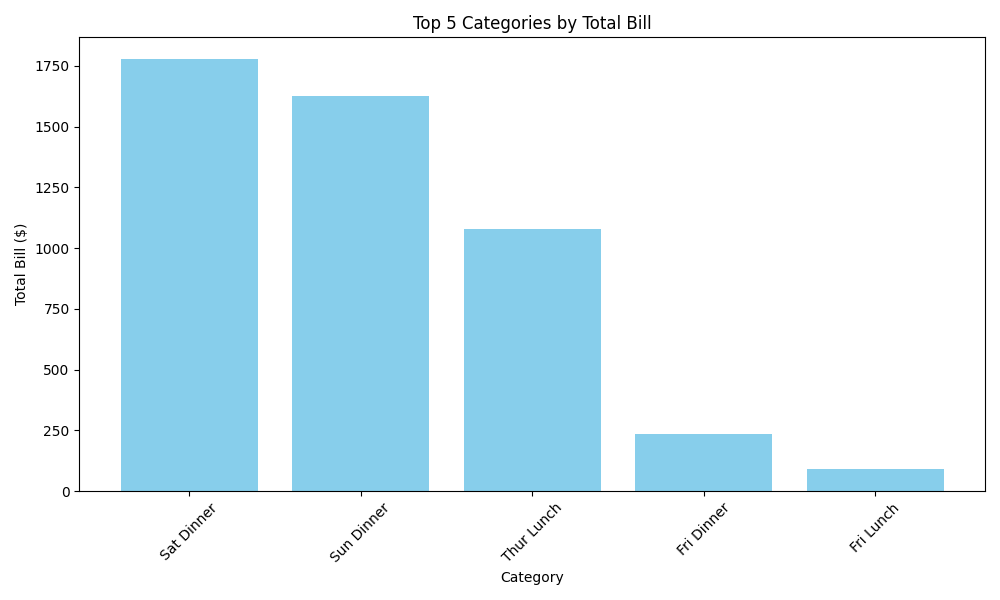

In [28]:
from IPython.display import Image, display
if os.path.exists("chart.png"):
    display(Image("chart.png"))
else:
    print("⚠️ chart.png was not generated.")